In [ ]:
import sys
import os
from pathlib import Path

# Add the project root to Python path
cwd = os.getcwd()
print(cwd)
project_root = Path(cwd).parent  # Go up to project root
# Sys.path is a list of dirs that python searches through for importing modules and files
# I'm adding the root to the path so the file can import things as if it were running from root
# This way I can keep my tests organized, but it still acts like I'm running from root
sys.path.insert(0, str(project_root))

import jsbgym
from jsbgym.control_system.ha_flight_evals import *
from jsbgym.control_system.basic_flight_pid import HAPIDControlSubsystem

d:\1DrvTK\OneDrive\GitHub\ADMBenchmark\control_system_evaluations


In [7]:
basic_flight_evaluator = HAFlightControlEval()
alt_cases = [AltCase.ALT_HOLD]
hdg_cases = [HdgCase.HDG_HOLD]
wind_cases = list(WindCase)
basic_flight_evaluator.batch_test(alt_cases,
hdg_cases,
wind_cases,
HAPIDControlSubsystem(),
2
)

=== CASE ALTITUDE: AltCase.ALT_HOLD HEADING: HdgCase.HDG_HOLD WIND: WindCase.CLM ===
--> EXAMPLE 0
Running simulation for 450.0 steps
Engines set to running!
Average steady state error:0.9471524441407786
Time to first conatact: 0.2
--> EXAMPLE 1
Running simulation for 450.0 steps
Engines set to running!
Average steady state error:0.9471524441407786
Time to first conatact: 0.2
=== CASE ALTITUDE: AltCase.ALT_HOLD HEADING: HdgCase.HDG_HOLD WIND: WindCase.WND_L_5 ===
--> EXAMPLE 0
Running simulation for 450.0 steps
Engines set to running!
Average steady state error:0.9471524441407786
Time to first conatact: 0.2
--> EXAMPLE 1
Running simulation for 450.0 steps
Engines set to running!
Average steady state error:0.9471524441407786
Time to first conatact: 0.2
=== CASE ALTITUDE: AltCase.ALT_HOLD HEADING: HdgCase.HDG_HOLD WIND: WindCase.WND_5_10 ===
--> EXAMPLE 0
Running simulation for 450.0 steps
Engines set to running!
Average steady state error:0.9471524441407786
Time to first conatact: 0.2
-

In [8]:
# Get batch evaluations
print(basic_flight_evaluator.create_batch_eval(list(range(len(basic_flight_evaluator.cases)))))

{'max alt overshoot': 0, 'max alt avg steady state error': 0.9471524441407786, 'avg alt steady state error': 0.9471524441407786, 'avg max alt overshoot': 0.0, 'avg hdg steady state error': 0.5833050002024913, 'max hdg overshoot': 0, 'avg time fufillment': 0.0, 'mean abs alt steady state error': 0.0}


In [9]:
indxs, criteria = basic_flight_evaluator.sort_evals()

In [11]:
print(indxs)
print(f"number of evals done: {len(indxs)}")
# Sanity check that it is sorted on the criteria correctly
print("Stall/Overspeed, SS error, max alt overshoot, exceeded expected time to first contact, max load factor")
for idx, c in enumerate(criteria):
    case_type = basic_flight_evaluator.cases[indxs[idx]]
    print(f"{case_type} : {c} : index {indxs[idx]}")


[9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
number of evals done: 10
Stall/Overspeed, SS error, max alt overshoot, exceeded expected time to first contact, max load factor
(<AltCase.ALT_HOLD: 'hold altitude'>, <HdgCase.HDG_HOLD: 'hold heading'>, <WindCase.WND_G_15: 'Max crosswind component greater than 15 knots. Steady.'>) : (0, 0, 0, 0, 1.0) : index 9
(<AltCase.ALT_HOLD: 'hold altitude'>, <HdgCase.HDG_HOLD: 'hold heading'>, <WindCase.WND_G_15: 'Max crosswind component greater than 15 knots. Steady.'>) : (0, 0, 0, 0, 1.0) : index 8
(<AltCase.ALT_HOLD: 'hold altitude'>, <HdgCase.HDG_HOLD: 'hold heading'>, <WindCase.WND_10_15: 'Max crosswind component between 10 and 15 knots. Steady wind.'>) : (0, 0, 0, 0, 1.0) : index 7
(<AltCase.ALT_HOLD: 'hold altitude'>, <HdgCase.HDG_HOLD: 'hold heading'>, <WindCase.WND_10_15: 'Max crosswind component between 10 and 15 knots. Steady wind.'>) : (0, 0, 0, 0, 1.0) : index 6
(<AltCase.ALT_HOLD: 'hold altitude'>, <HdgCase.HDG_HOLD: 'hold heading'>, <WindCase.WND_5_10:

{'atmosphere/psiw-rad': 6.283185307179586, 'atmosphere/wind-mag-fps': 0, 'ic/h-sl-ft': 5000, 'ic/psi-true-deg': 0, 'ic/u-fps': 168.78, 'altitude change desired': 0, 'heading change desired': 0}
{'max alt overshoot': 0, 'max hdg overshoot': 0, 'max load factor': 1.0001445420504236, 'avg load factor': 0.9980079238134296, 'min airspeed': 92.87350214418638, 'max airspeed': 93.0803184484454, 'avg airspeed': 92.98530307866282, 'avg alt steady state error': 0.9471524441407786, 'avg hdg steady state error': 0.5833050002024912, 'time to first contact s': 0.2, 'max man time mins': 0.0, 'max time mins': 1.5}


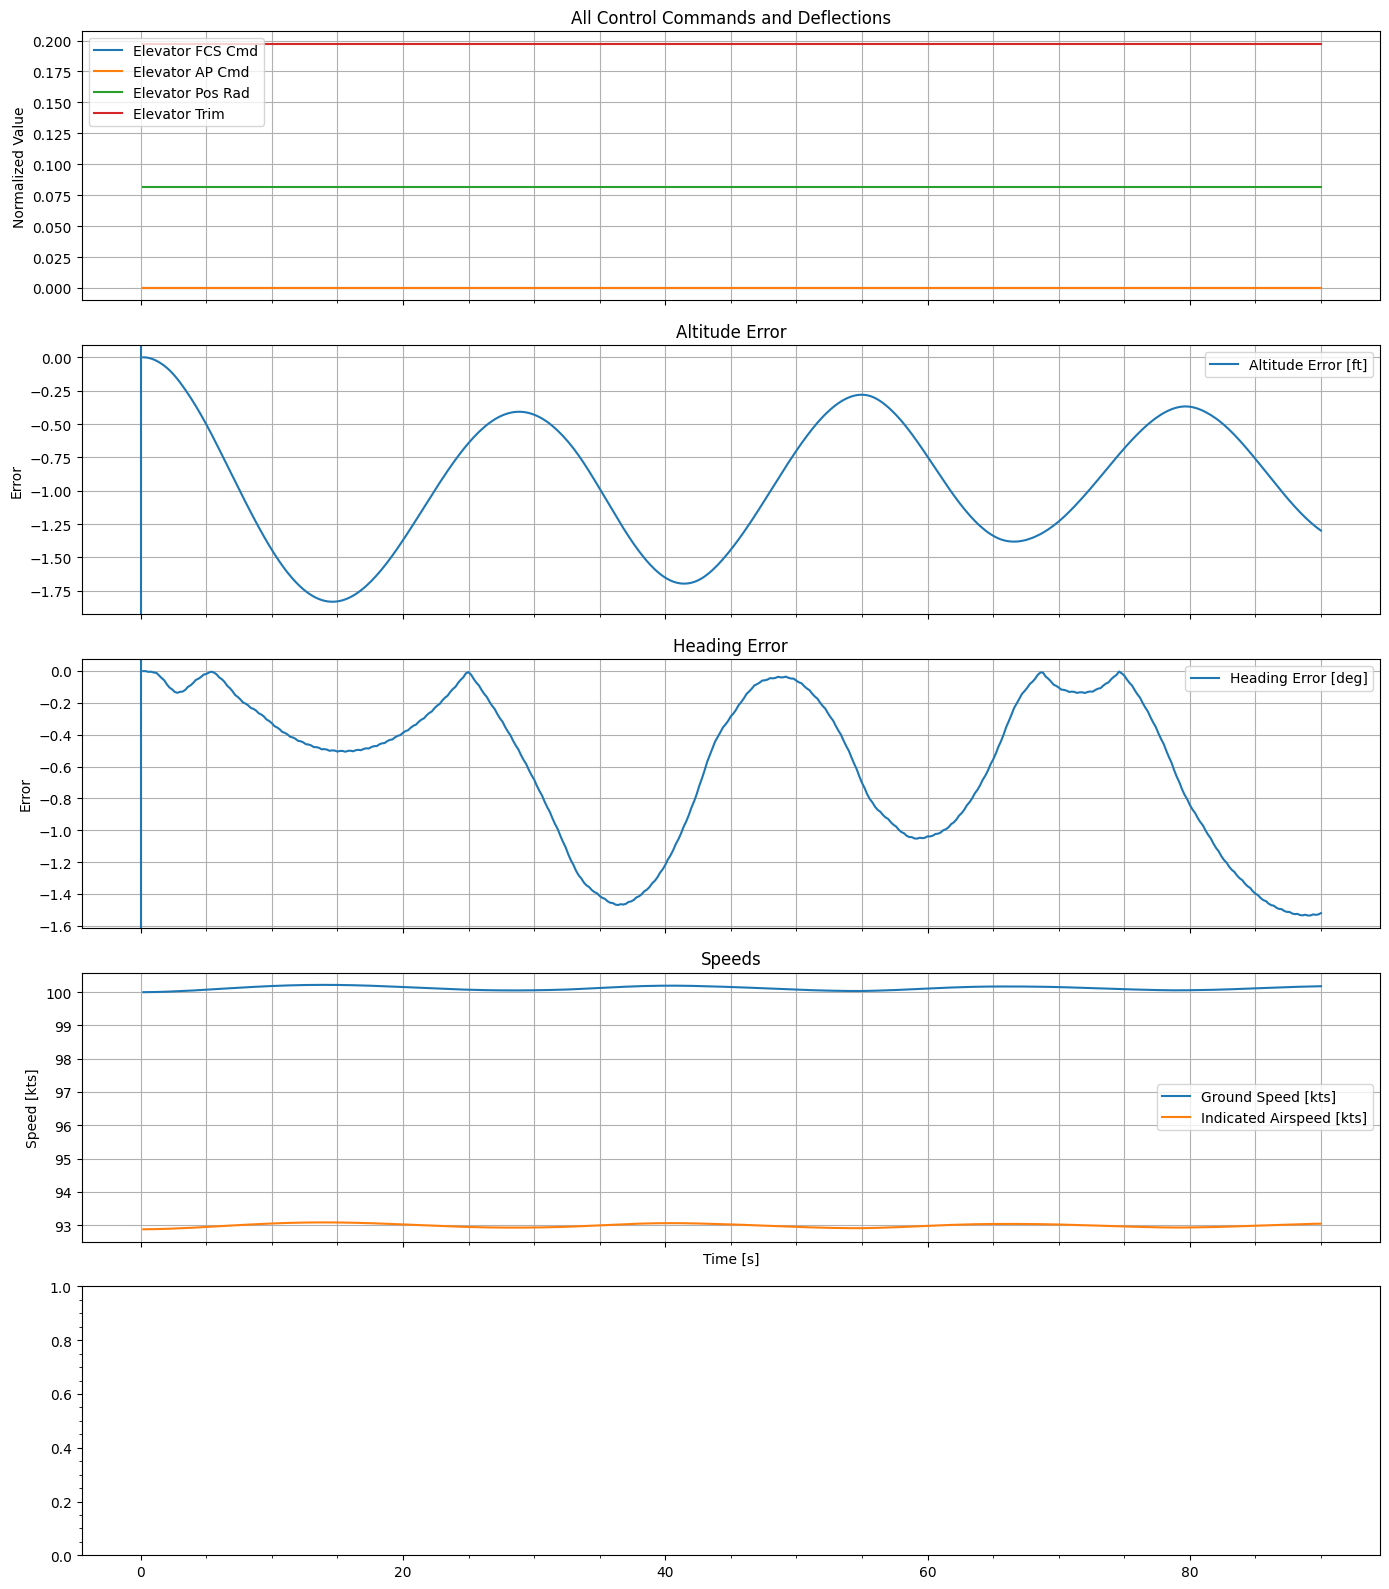

In [6]:
# Get the trajectory data and precise evaluation for an individual index for analysis
selected_index = 0
print(basic_flight_evaluator.initial_conditions[selected_index])
eval = basic_flight_evaluator.evals[selected_index]
print(eval)
basic_flight_evaluator.plot_eval(selected_index)

In [ ]:
# Run a single simulation from initial conditions
basic_flight_evaluator.run_single_eval(AltCase.ALT_HOLD, HdgCase.HDG_HOLD, HAPIDControlSubsystem(), "flightgear")